<a href="https://colab.research.google.com/github/vijaydevverse/eda-ml-projects/blob/main/SyntheticFinanceEdaV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df=pd.read_csv('/content/financial_200_features_dataset (1).csv')
df

,company,year,revenue,domestic_sales,export_sales,cogs,gross_profit,operating_expense,ebit,ebitda,...,ebitda_margin_rolling_std,ebitda_margin_momentum,net_margin_lag1,net_margin_lag2,net_margin_rolling_mean,net_margin_rolling_std,net_margin_momentum,profit_growth_lag1,profit_growth_lag2,profit_growth_rolling_mean
0,Company_1,2016,8.165607e+09,6.857467e+09,1.308140e+09,4.273901e+09,3.891705e+09,1.622664e+09,2.269041e+09,2.691550e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Company_1,2017,8.255296e+09,6.220030e+09,2.035266e+09,4.777473e+09,3.477822e+09,1.882070e+09,1.595753e+09,2.020075e+09,...,NaN,-0.084920,0.228759,NaN,NaN,NaN,-0.065468,NaN,NaN,NaN
2,Company_1,2018,9.701681e+09,8.647402e+09,1.054279e+09,5.670567e+09,4.031114e+09,2.195005e+09,1.836109e+09,2.325840e+09,...,0.050523,-0.004965,0.163291,0.228759,0.174602,0.049480,-0.031534,-0.278348,NaN,NaN
3,Company_1,2019,1.187694e+10,9.919089e+09,1.957854e+09,5.994258e+09,5.882686e+09,3.338302e+09,2.544384e+09,3.298482e+09,...,0.020648,0.037986,0.131757,0.163291,0.150409,0.016540,0.024423,-0.051746,-0.278348,0.040348
4,Company_1,2020,1.492980e+10,1.151294e+10,3.416853e+09,9.261393e+09,5.668402e+09,2.820926e+09,2.847476e+09,4.035986e+09,...,0.020140,-0.007390,0.156179,0.131757,0.147121,0.013377,-0.002751,0.451138,-0.051746,0.211430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Company_100,2021,8.559483e+09,6.686524e+09,1.872959e+09,4.788898e+09,3.770584e+09,1.654942e+09,2.115643e+09,2.551793e+09,...,0.074160,0.095876,0.111521,0.062018,0.122222,0.066207,0.081608,1.179173,-0.692093,0.421896
996,Company_100,2022,9.714145e+09,8.694084e+09,1.020060e+09,5.722835e+09,3.991310e+09,2.682451e+09,1.308859e+09,1.871674e+09,...,0.058315,-0.105450,0.193128,0.111521,0.132629,0.053185,-0.099888,0.778608,1.179173,0.501898
997,Company_100,2023,1.083203e+10,9.011670e+09,1.820361e+09,6.557667e+09,4.274364e+09,3.249512e+09,1.024852e+09,1.707906e+09,...,0.073112,-0.035003,0.093240,0.193128,0.118656,0.065569,-0.023641,-0.452086,0.778608,0.052959
998,Company_100,2024,1.246219e+10,1.021536e+10,2.246830e+09,8.058580e+09,4.403611e+09,3.257115e+09,1.146496e+09,1.921861e+09,...,0.021277,-0.003457,0.069599,0.093240,0.074372,0.016991,-0.009321,-0.167646,-0.452086,-0.207772


In [17]:
df.isnull().sum()

,0
company,0
year,0
revenue,0
domestic_sales,0
export_sales,0
...,...
net_margin_rolling_std,200
net_margin_momentum,100
profit_growth_lag1,200
profit_growth_lag2,300


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 210 entries, company to profit_growth_rolling_mean
dtypes: float64(206), int64(3), object(1)
memory usage: 1.6+ MB


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.shape

(1000, 210)

In [21]:
df = pd.get_dummies(df, columns=["company"], drop_first=True)

In [22]:
df.head()

,year,revenue,domestic_sales,export_sales,cogs,gross_profit,operating_expense,ebit,ebitda,net_profit,...,company_Company_90,company_Company_91,company_Company_92,company_Company_93,company_Company_94,company_Company_95,company_Company_96,company_Company_97,company_Company_98,company_Company_99
0,2016,8.165607e+09,6.857467e+09,1.308140e+09,4.273901e+09,3.891705e+09,1.622664e+09,2.269041e+09,2.691550e+09,1.867955e+09,...,False,False,False,False,False,False,False,False,False,False
1,2017,8.255296e+09,6.220030e+09,2.035266e+09,4.777473e+09,3.477822e+09,1.882070e+09,1.595753e+09,2.020075e+09,1.348014e+09,...,False,False,False,False,False,False,False,False,False,False
2,2018,9.701681e+09,8.647402e+09,1.054279e+09,5.670567e+09,4.031114e+09,2.195005e+09,1.836109e+09,2.325840e+09,1.278260e+09,...,False,False,False,False,False,False,False,False,False,False
3,2019,1.187694e+10,9.919089e+09,1.957854e+09,5.994258e+09,5.882686e+09,3.338302e+09,2.544384e+09,3.298482e+09,1.854932e+09,...,False,False,False,False,False,False,False,False,False,False
4,2020,1.492980e+10,1.151294e+10,3.416853e+09,9.261393e+09,5.668402e+09,2.820926e+09,2.847476e+09,4.035986e+09,2.290649e+09,...,False,False,False,False,False,False,False,False,False,False


In [24]:
df["year"].unique()

array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

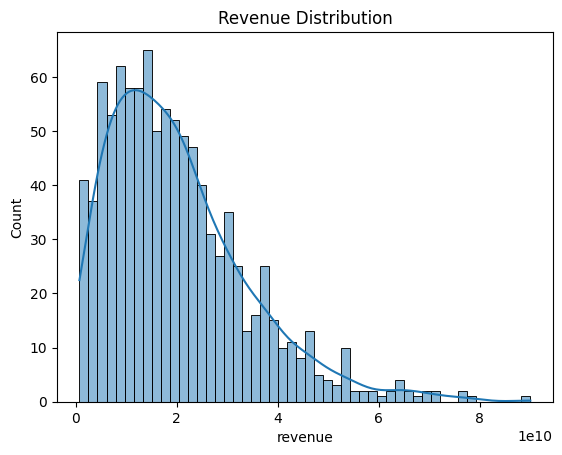

In [26]:
sns.histplot(df["revenue"], bins=50, kde=True)
plt.title("Revenue Distribution")
plt.show()

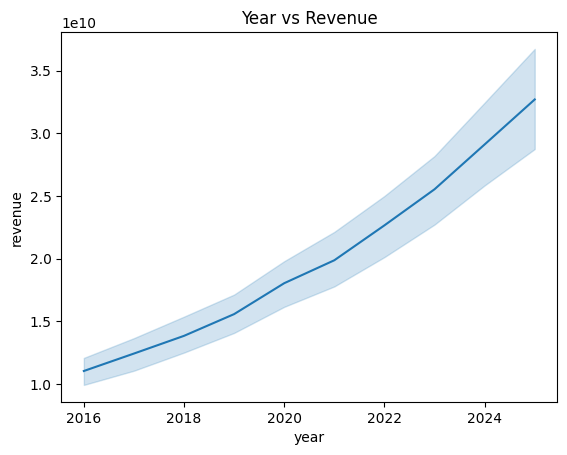

In [27]:
sns.lineplot(x="year", y="revenue", data=df)
plt.title("Year vs Revenue")
plt.show()

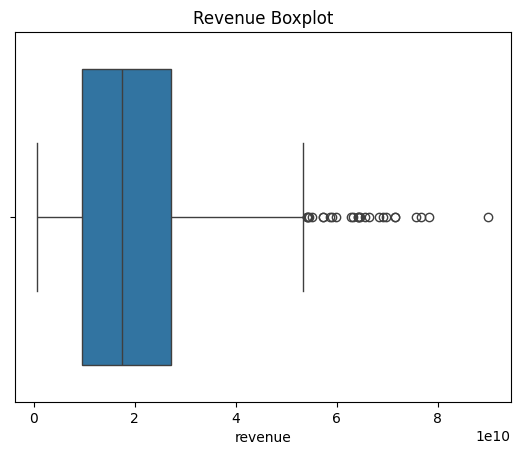

In [30]:
sns.boxplot(x=df["revenue"])
plt.title("Revenue Boxplot")
plt.show()

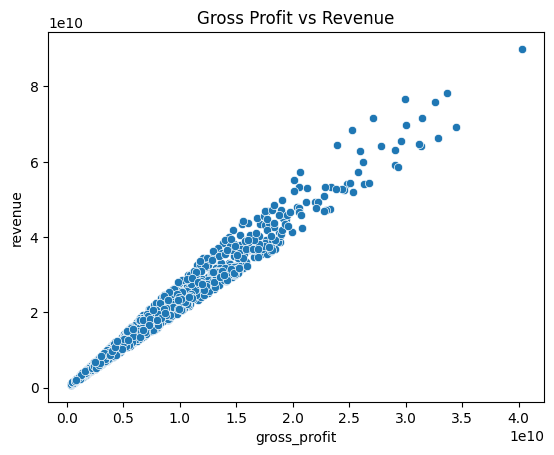

In [31]:
sns.scatterplot(x="gross_profit", y="revenue", data=df)
plt.title("Gross Profit vs Revenue")
plt.show()

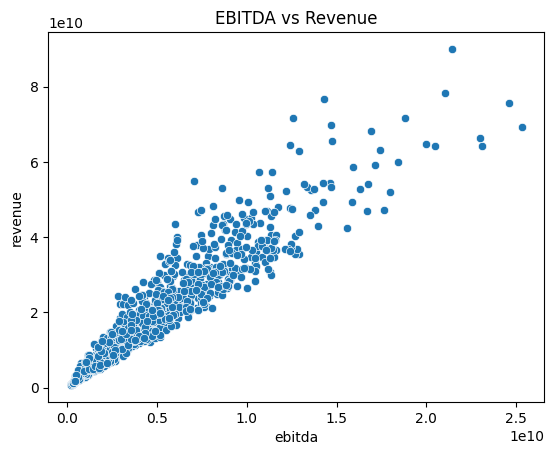

In [32]:
sns.scatterplot(x="ebitda", y="revenue", data=df)
plt.title("EBITDA vs Revenue")
plt.show()

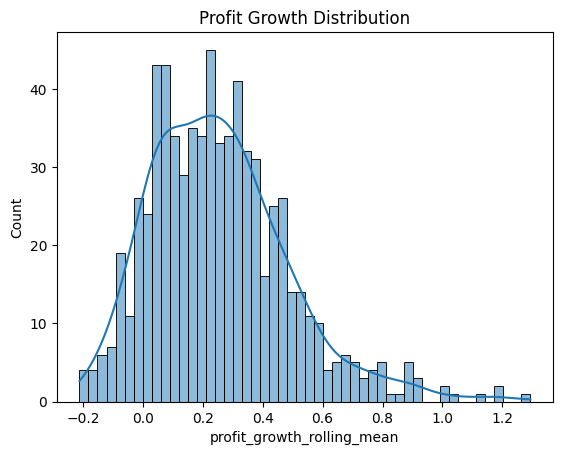

In [34]:
sns.histplot(df["profit_growth_rolling_mean"], bins=50, kde=True)
plt.title("Profit Growth Distribution")
plt.show()

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 308 entries, year to company_Company_99
dtypes: bool(99), float64(206), int64(3)
memory usage: 1.7 MB


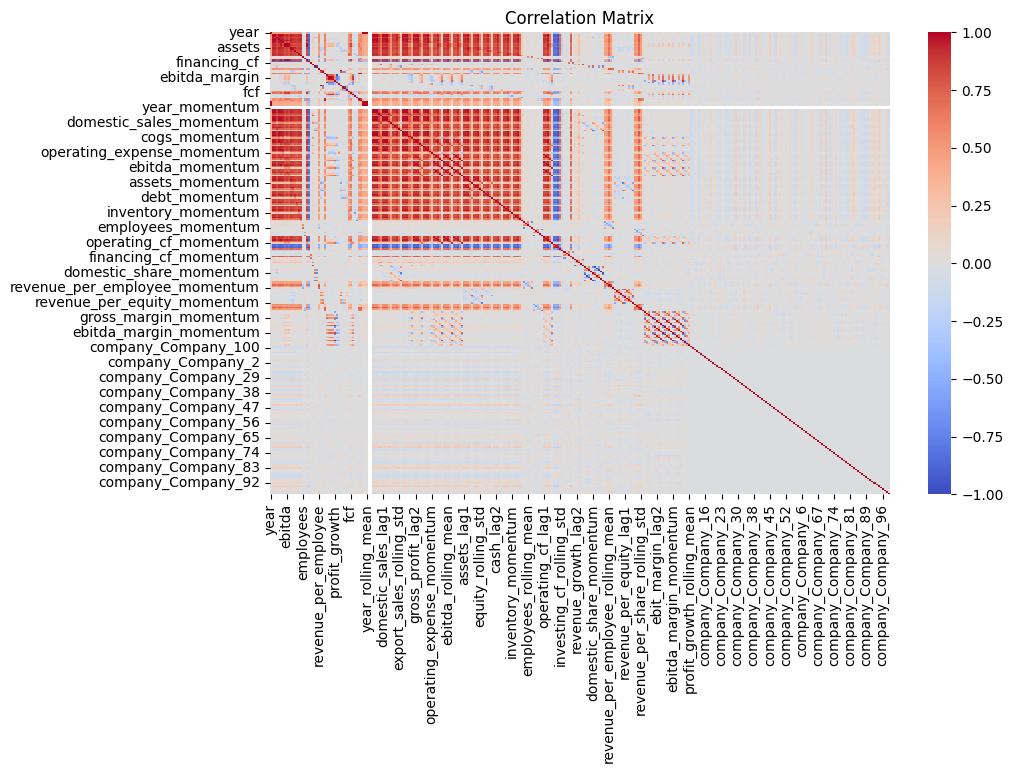

In [37]:
plt.figure(figsize=(10,6))
cm=df.corr()
sns.heatmap(cm,annot=False,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

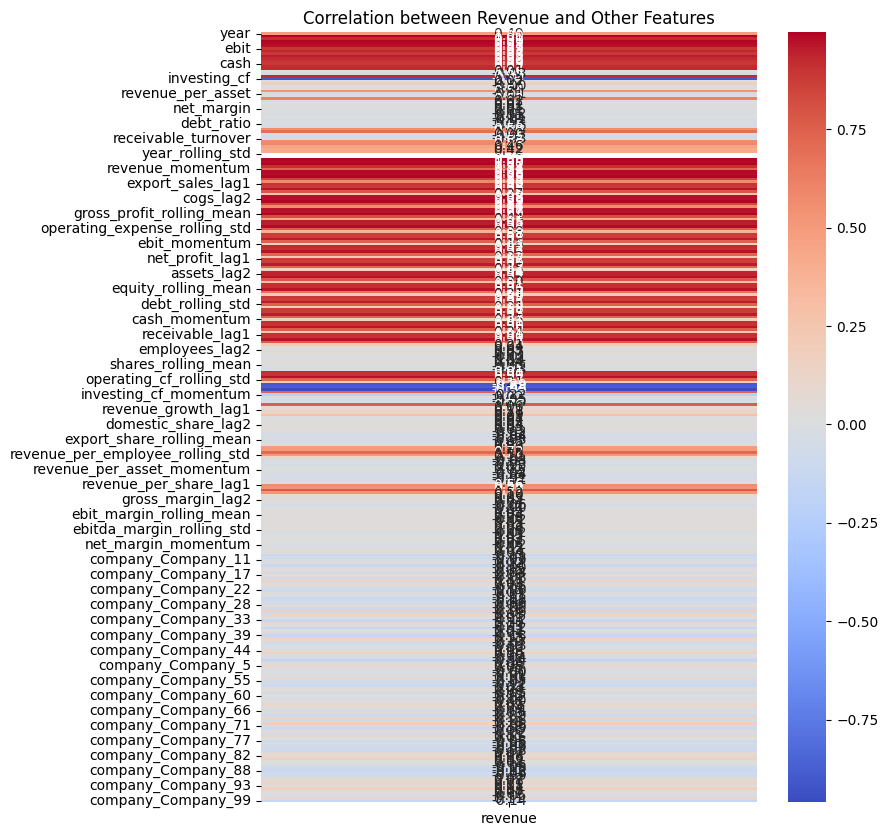

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

target_corr = df.corr()["revenue"]
target_corr = target_corr.drop("revenue")

plt.figure(figsize=(8,10))
sns.heatmap(target_corr.to_frame(), annot=True, fmt=".2f", cmap="coolwarm",
            cbar=True, annot_kws={"size":10})

plt.title("Correlation between Revenue and Other Features")
plt.show()

<Axes: >

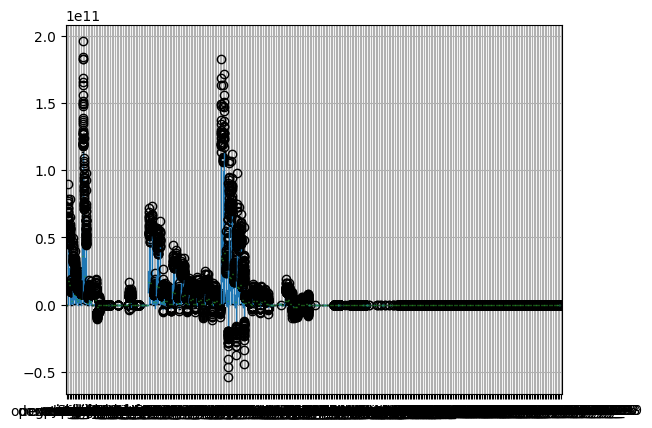

In [39]:
df.boxplot()

In [41]:
def remove_outliers_iqr(df,exclude_column):

    for col in df.select_dtypes(include=np.number).columns:
        if col==exclude_column:
            continue
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
    return df

df=remove_outliers_iqr(df,exclude_column='revenue')

In [42]:
df.shape

(10, 308)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 244 to 987
Columns: 308 entries, year to company_Company_99
dtypes: bool(99), float64(206), int64(3)
memory usage: 17.4 KB


In [44]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=["revenue","domestic_sales","export_sales","cogs","gross_profit","operating_expense","ebit","ebitda"]

scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)
scaled_df.head()

,revenue,domestic_sales,export_sales,cogs,gross_profit,operating_expense,ebit,ebitda
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.315251,0.311938,0.478707,0.243626,0.407462,0.332711,0.497628,0.488451
2,0.479542,0.478876,0.589843,0.441573,0.528425,0.446664,0.622296,0.576876
3,0.000000,0.000000,0.202299,0.000000,0.000000,0.027106,0.000000,0.000000
4,0.034059,0.053067,0.086395,0.004813,0.071712,0.000000,0.167897,0.129034


In [45]:
df

,year,revenue,domestic_sales,export_sales,cogs,gross_profit,operating_expense,ebit,ebitda,net_profit,...,company_Company_90,company_Company_91,company_Company_92,company_Company_93,company_Company_94,company_Company_95,company_Company_96,company_Company_97,company_Company_98,company_Company_99
244,2020,4.140448e+09,3.615043e+09,5.254045e+08,2.366691e+09,1.773757e+09,9.195864e+08,8.541709e+08,1.106228e+09,6.928546e+08,...,False,False,False,False,False,False,False,False,False,False
385,2021,1.915621e+09,1.593676e+09,3.219447e+08,9.835200e+08,9.321010e+08,4.408957e+08,4.912053e+08,6.360235e+08,4.033929e+08,...,False,False,False,False,False,False,False,False,False,False
389,2025,2.449422e+09,2.084101e+09,3.653208e+08,1.345502e+09,1.103920e+09,5.226417e+08,5.812785e+08,7.173024e+08,4.356702e+08,...,False,False,False,False,False,False,False,False,False,False
473,2019,8.913360e+08,6.772728e+08,2.140631e+08,5.380035e+08,3.533324e+08,2.216654e+08,1.316671e+08,1.870507e+08,9.515872e+07,...,False,False,False,False,False,False,False,False,False,False
474,2020,1.001998e+09,8.331726e+08,1.688258e+08,5.468047e+08,4.551937e+08,2.022203e+08,2.529734e+08,3.056558e+08,2.005633e+08,...,False,False,False,False,False,False,False,False,False,False
477,2023,1.320202e+09,1.111140e+09,2.090621e+08,6.680471e+08,6.521553e+08,3.804475e+08,2.717078e+08,3.597955e+08,2.238044e+08,...,False,False,False,False,False,False,False,False,False,False
874,2020,2.399527e+09,2.074278e+09,3.252490e+08,1.260437e+09,1.139091e+09,6.137435e+08,5.253473e+08,6.514902e+08,4.409626e+08,...,False,False,False,False,False,False,False,False,False,False
985,2021,1.145401e+09,1.010295e+09,1.351062e+08,5.842073e+08,5.611938e+08,3.254103e+08,2.357835e+08,3.065173e+08,1.704901e+08,...,False,False,False,False,False,False,False,False,False,True
986,2022,1.355413e+09,1.211603e+09,1.438102e+08,8.707179e+08,4.846951e+08,2.457994e+08,2.388957e+08,3.148574e+08,2.027637e+08,...,False,False,False,False,False,False,False,False,False,True
987,2023,1.663072e+09,1.339326e+09,3.237457e+08,9.048279e+08,7.582438e+08,4.646207e+08,2.936231e+08,4.086341e+08,2.436049e+08,...,False,False,False,False,False,False,False,False,False,True


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

y = df["revenue"]

X = df[["domestic_sales","export_sales","cogs","gross_profit","ebitda"]]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test,y_pred)
print(f'Baseline model R2 Score: {r2:.2f}')

Baseline model R2 Score: 1.00
